# **Notebook 01: Análisis Exploratorio y Preprocesamiento de Datos**

**Integrantes:**
- Gino Andrades
- Yai Selti
- Miguel Villarroel

**Correo Electrónico:**
- gi.andrades@duocuc.cl
- ya.selti@duocuc.cl
- mig.villarroel@duocuc.cl

**Fecha de Entrega:** 25 de Mayo de 2026

**Versión:** 1.3 (Final - Preprocesamiento)

---

### **Caso de Estudio**
El actual problema de la empresa es la disminución en la tasa de retención de sus clientes, lo que afecta directamente en los ingresos y los elevados costos en la adquisición de nuevos clientes. El objetivo es generar una solución analítica que permita anticipar comportamiento y diseñar soluciones preventivas basadas en los datos, utilizando para ello diversas tecnologías en el análisis de datos que permiten procesar grandes volúmenes de información de manera eficiente. Z

### **Descripción Técnica**
Este notebook aborda la fase inicial del proyecto. El objetivo es transformar los datos transaccionales y demográficos crudos en un conjunto de entrenamiento optimizado mediante técnicas de limpieza estructural, ingeniería de características (ratios de estrés financiero y lealtad) y pipelines de transformación estadística, garantizando la integridad y robustez necesaria para el modelamiento predictivo en la siguiente etapa.

Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

In [1]:
import pandas as pd
print(pd.__version__)

2.3.1


## **1. Configuración del Entorno (Code)**

### 1.1 Importaciones necesarias para trabajar.

In [2]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import FunctionTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin


### *1.2 Cargar los registros a la variable "data" con pandas*

In [3]:
ruta_dataset = "../data/data_sucia/dataset_clientes.csv"
data = pd.read_csv(ruta_dataset)

###*1.4 Variable Objetivo*

In [4]:
target = "abandono"

##**2. Exploración Inicial y Perfilamiento**

###*2.1 Inspección Estructural del Dataset*

In [5]:
# Revision de Estado
# Cantidad de observaciones y columnas
data.shape

(20400, 22)

In [6]:
# Ejecutamos df.info() para obtener un resumen técnico de la estructura del DataFrame.
# Esto nos confirmará la correcta separación de columnas y nos guiará en el tratamiento
# diferenciado que daremos a variables numéricas (int64/float64) y categóricas (object).
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20400 non-null  int64  
 1   fecha_registro         20400 non-null  object 
 2   edad                   20400 non-null  int64  
 3   genero                 20400 non-null  object 
 4   region                 20400 non-null  object 
 5   estado_civil           20400 non-null  object 
 6   ingreso_mensual        19379 non-null  float64
 7   gasto_mensual          19375 non-null  float64
 8   deuda_total            20400 non-null  float64
 9   score_crediticio       19379 non-null  float64
 10  antiguedad_meses       20400 non-null  int64  
 11  frecuencia_compra      20400 non-null  int64  
 12  ultima_compra_dias     20400 non-null  int64  
 13  uso_app                20400 non-null  object 
 14  tipo_plan              20400 non-null  object 
 15  nu

**Observacion**: A simple vista, podemos observa la existencia de tres columnas con valores nulos: ingreso_mensual, gasto_mensual y score_crediticio. Al ser variables críticas para el análisis del perfil del cliente, su manipulación requiere un criterio técnico riguroso. Se deben abordar mediante una estrategia avanzada de preprocesamiento estructurado para preservar la distribución de los datos y asegurar que el futuro modelo no herede sesgos artificiales que comprometan su precisión.

### *2.2 Consolidación de una nueva Tabla*

In [7]:
# Calculamos la densidad de clientes por Región y nivel de Uso de la App
tabla_densidad_uso = data.groupby(['region', 'uso_app'])['id_cliente'].count().reset_index()

# Renombramos para dar contexto de negocio
tabla_densidad_uso = tabla_densidad_uso.rename(columns={'id_cliente': 'volumen_interaccion_zonal'})

print("Tabla: Densidad de Interacción Zonal")
display(tabla_densidad_uso)

Tabla: Densidad de Interacción Zonal


,region,uso_app,volumen_interaccion_zonal
0,Centro,Alto,2308
1,Centro,Bajo,2268
2,Centro,Medio,2211
3,Norte,Alto,2263
4,Norte,Bajo,2283
5,Norte,Medio,2255
6,Sur,Alto,2230
7,Sur,Bajo,2335
8,Sur,Medio,2247


In [8]:
# Antes de hacer el merge, eliminamos la columna si es que ya existía por error
if 'volumen_interaccion_zonal' in data.columns:
    data = data.drop(columns=['volumen_interaccion_zonal'])

# Ejecutamos un left join
data = pd.merge(
    left=data,
    right=tabla_densidad_uso,
    how='left',
    on=['region', 'uso_app']
)

print("\n Visualizacion del Cruce")
print(f"Dimensiones post-Join: {data.shape}")
display(data[['region', 'uso_app', 'volumen_interaccion_zonal']].head())


 Visualizacion del Cruce
Dimensiones post-Join: (20400, 23)


,region,uso_app,volumen_interaccion_zonal
0,Norte,Bajo,2283
1,Centro,Medio,2211
2,Norte,Alto,2263
3,Sur,Alto,2230
4,Centro,Bajo,2268


**Observación:** Tras ejecutar el Left Join multivariable (on=['region', 'uso_app']), se consolidan las siguientes conclusiones analíticas:

* Integridad Coherente de los Datos: El dataset final mantiene exactamente 20,400 filas y 23 columnas. Conservar el volumen original de registros demuestra un acople limpio mediante llaves únicas, descartando pérdidas de información o duplicaciones artificiales que inflen la muestra.

* Equilibrio Estadístico (Sin Sesgos): La nueva variable volumen_interaccion_zonal revela una distribución simétrica y balanceada, promediando 2,260 usuarios por combinación. Esto es ideal para el modelamiento matemático, ya que evita que los algoritmos de Machine Learning desarrollen sesgos predictivos hacia una región o conducta específica.

* Inyección de Contexto: El mapeo es consistente (ej. Norte-Bajo asigna 2283 y Centro-Medio 2211). Al aportar este indicador de densidad grupal, el modelo adquiere una variable macroambiental clave para evaluar si la fuga de clientes responde a un comportamiento aislado o a fallas de infraestructura localizadas en su zona.

###*2.3 Visualización Preliminar de Registros*

In [9]:
# Desplegamos las primeras 5 filas del dataset para una validación visual.
# Esta muestra nos permite entender el formato real de los datos con los que
# interactuaremos.
data.head()

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono,volumen_interaccion_zonal
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1,2283
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,Medio,Premium,4,1,App,Martes,10,4148,0,2211
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,Alto,Premium,4,1,App,Jueves,6,7200,0,2263
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,Alto,Estandar,2,1,App,Domingo,16,1782,1,2230
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,Bajo,Estandar,3,1,Web,Martes,8,3448,1,2268


**Observacion:** El análisis visual de los primeros cinco registros confirma que la estructura relacional del dataset se cargó de acuerdo con los parámetros esperados. Esta vista preliminar resulta clave para auditar el comportamiento inicial de las celdas y analizar la naturaleza de las variables (numéricas, nominales y ordinales).

###*2.4 Análisis Estadístico Descriptivo*

In [10]:
# .describe para ver el estadistico descriptivo, tambien podemos agregarle el .style.format(precision=0)
# para vizualizar los valores sin decimales(sirve para analizar las columnas monetarias)
display(data.drop(columns=['id_cliente']).describe())

,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,codigo_postal,abandono,volumen_interaccion_zonal
count,20400.00000,1.937900e+04,19375.000000,2.040000e+04,19379.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000
mean,48.54598,8.330390e+05,399453.495188,2.061953e+06,600.441593,60.205882,9.966765,182.325686,2.994853,0.501373,11.416716,5488.970147,0.396814,2267.236569
std,17.84971,4.301978e+05,150831.135171,1.055155e+06,100.408685,34.210052,5.460586,105.056827,1.410716,0.500010,6.891420,2602.374998,0.489249,36.048684
min,18.00000,-8.302577e+04,-194957.467079,-1.684124e+06,220.516968,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1000.000000,0.000000,2211.000000
25%,33.00000,6.346396e+05,296753.420113,1.461942e+06,532.872163,31.000000,5.000000,92.000000,2.000000,0.000000,6.000000,3239.000000,0.000000,2247.000000
50%,48.00000,8.044483e+05,398887.260180,2.017759e+06,600.955064,61.000000,10.000000,181.000000,3.000000,1.000000,11.000000,5477.500000,0.000000,2263.000000
75%,64.00000,9.737937e+05,500485.426137,2.557871e+06,668.245607,90.000000,15.000000,274.000000,4.000000,1.000000,17.000000,7775.000000,1.000000,2283.000000
max,79.00000,7.560936e+06,954575.217321,1.777694e+07,998.290682,119.000000,19.000000,364.000000,5.000000,1.000000,23.000000,9998.000000,1.000000,2335.000000


In [11]:
# sin decimales y con puntos para separar los miles (Porposito: SOLO para mayor claridad al observar los valores monetarios)
display(data.drop(columns=['id_cliente', 'edad', 'score_crediticio', 'antiguedad_meses', 'frecuencia_compra', 'ultima_compra_dias', 'num_productos', 'hora_registro', 'codigo_postal', 'abandono', 'tiene_tarjeta_credito']).describe().style.format(precision=0, thousands="."))

,ingreso_mensual,gasto_mensual,deuda_total,volumen_interaccion_zonal
count,19.379,19.375,20.400,20.400
mean,833.039,399.453,2.061.953,2.267
std,430.198,150.831,1.055.155,36
min,-83.026,-194.957,-1.684.124,2.211
25%,634.640,296.753,1.461.942,2.247
50%,804.448,398.887,2.017.759,2.263
75%,973.794,500.485,2.557.871,2.283
max,7.560.936,954.575,17.776.941,2.335


**Observación:** El análisis de las medidas de tendencia central y dispersión (`.describe()`) permite identificar con precisión las variables cuantitativas que presentan anomalías estructurales severas, aislando los problemas para el correcto diseño de nuestra estrategia de preprocesamiento:

* **Anomalía de Signo (Errores de Captura):** Se detectan valores mínimos (`min`) negativos extremos en las variables financieras `ingreso_mensual` (-83.026), `gasto_mensual` (-194.957) y `deuda_total` (-1.684.124). Al ser dimensiones económicas que bajo ninguna circunstancia admiten saldos menores a cero en este contexto de negocio, se determina que corresponden a un error de guion tipográfico durante el registro en los sistemas origen. Se resolverá formalmente mediante la aplicación de **Valor Absoluto (`np.abs()`)** en la fase de limpieza inicial externa, rescatando la magnitud real de la información sin destruir filas ni alterar artificialmente la varianza de la muestra.

* **Presencia de Outliers Atípicos:** La columna `deuda_total` evidencia una marcada y severa asimetría hacia la derecha. Mientras que el 75% de la muestra acumulada deudas inferiores a 2.557.871, el valor máximo (`max`) se dispara de forma atípica hasta alcanzar los $17.776.941. Para mitigar el impacto de esta dispersión en modelos sensibles a los valores extremos, se implementará un transformador personalizado de **Winsorización** dentro de la canalización.

* **Disparidad de Escalas Numéricas:** Coexisten variables con magnitudes en el orden de los millones (`ingreso_mensual`) frente a dimensiones de un solo dígito o rangos acotados (como `num_productos` o `frecuencia_compra`). Dado que el resto de las columnas cuantitativas no presentan nulos ni valores fuera de rango, su único requerimiento técnico es la homogeneización de magnitudes. Se incorporará un **`StandardScaler`** como componente base del pipeline estadístico para evitar distorsiones geométricas en el cálculo de distancias y optimizar la convergencia matemática del algoritmo.

###*2.5 Detección de Registros Duplicados*

#### *2.5.1 Conteo de registros duplicados*

In [12]:
# Revisa la existencia de duplicados
data.duplicated().sum()

np.int64(400)

#### *2.5.2 Identificar los registros duplicados*

In [13]:
# Obtiene los registos duplicados
data[data.duplicated(keep=False)].sort_values(by='id_cliente')

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono,volumen_interaccion_zonal
20032,178,2022-02-16,58,Otro,Centro,Soltero,574734.320058,124060.694605,1.567047e+06,706.773275,...,Alto,Premium,2,0,Tienda,Sabado,11,8146,1,2308
177,178,2022-02-16,58,Otro,Centro,Soltero,574734.320058,124060.694605,1.567047e+06,706.773275,...,Alto,Premium,2,0,Tienda,Sabado,11,8146,1,2308
215,216,2021-05-23,77,Femenino,Centro,Divorciado,696251.283767,755824.522948,2.522168e+06,691.380909,...,Alto,Estandar,5,1,App,Sabado,6,4541,1,2308
20300,216,2021-05-23,77,Femenino,Centro,Divorciado,696251.283767,755824.522948,2.522168e+06,691.380909,...,Alto,Estandar,5,1,App,Sabado,6,4541,1,2308
20348,327,2019-07-15,43,Femenino,Sur,Soltero,611018.691110,238932.156632,8.764364e+05,618.183493,...,Medio,Basico,3,0,App,Lunes,11,6291,0,2247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19921,19922,2020-01-22,52,Masculino,Sur,Casado,892522.042338,161697.180367,1.750559e+06,662.274443,...,Bajo,Premium,1,0,App,Viernes,3,4398,1,2335
19923,19924,2018-01-17,54,Otro,Centro,Casado,822109.701169,489936.535727,2.022070e+06,584.830157,...,Bajo,Estandar,1,0,Tienda,Miercoles,17,8097,1,2268
20289,19924,2018-01-17,54,Otro,Centro,Casado,822109.701169,489936.535727,2.022070e+06,584.830157,...,Bajo,Estandar,1,0,Tienda,Miercoles,17,8097,1,2268
20147,19983,2022-02-17,26,Otro,Centro,Soltero,947809.404071,221838.916723,3.226056e+06,556.285263,...,Alto,Basico,1,1,Tienda,Jueves,5,6118,1,2308


**Observación:** La ejecución del método .duplicated().sum() detecto un total de 400 registros completamente idénticos en la matriz de datos. Esto distorsiona el peso real de las observaciones, introduciendo un sesgo artificial en las distribuciones de los perfiles de clientes y violando el principio de independencia estadística que exigen los modelos predictivos. Determinamos la eliminación inmediata de estas filas mediante el método .drop_duplicates() en la etapa de limpieza inicial externa, garantizando una base depurada de 20.000 registros únicos listos para entrar a la canalización de procesamiento estadístico.

###*2.6 Detección de Valores Atípicos (Outliers)*

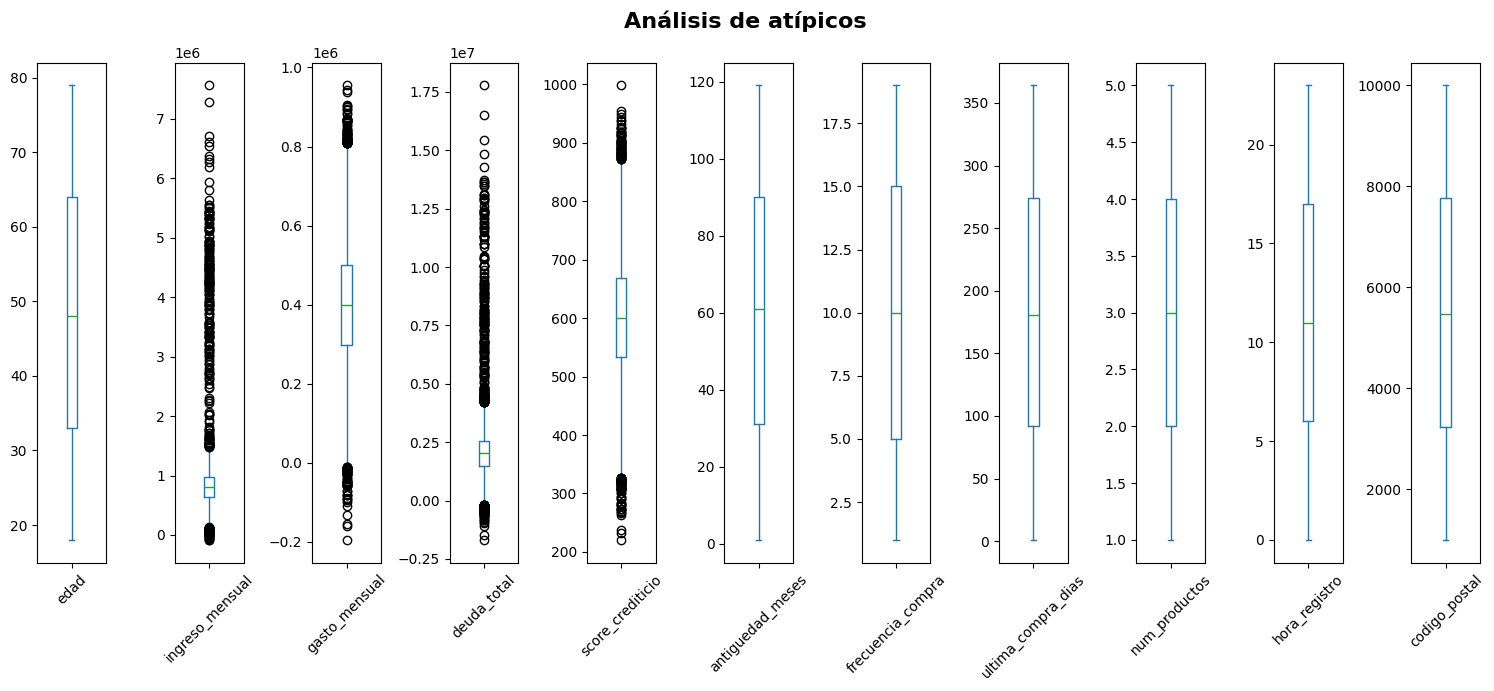

In [14]:
revision_atipicos = ['edad', 'ingreso_mensual', 'gasto_mensual',	'deuda_total', 'score_crediticio', 'antiguedad_meses', 'frecuencia_compra', 'ultima_compra_dias', 'num_productos', 'hora_registro', 'codigo_postal' ]
fig, axes = plt.subplots(1, 11 , figsize=(20,20))
axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos):
  data[col].plot(kind='box',figsize=(15,7), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

**Observaciones**:
La visualización de las distribuciones mediante diagramas de caja (*Boxplots*) corrobora de manera gráfica los hallazgos numéricos obtenidos en el resumen estadístico, revelando la verdadera magnitud del "ruido" físico en nuestro dataset crudo:

* **Valores Negativos:** En los gráficos correspondientes a `ingreso_mensual`, `gasto_mensual` y `deuda_total`, se aprecian claramente puntos individuales (*outliers* inferiores) que descienden más allá de la marca del cero en el eje Y. Al tratarse de flujos monetarios que no pueden ser negativos, esta representación visual ratifica la necesidad de aplicar **Valor Absoluto** como primer paso de limpieza externa, ya que estos valores están estirando artificialmente la cola inferior de las distribuciones.

* **Aplastamiento Intercuartílico por Outliers Severos:** El caso más extremo de distorsión lo presenta la variable `deuda_total`. La caja central (el Rango Intercuartílico que contiene al 50% central de los clientes) se ve completamente "aplastada" contra la base del gráfico. Esto ocurre porque el eje Y se ha tenido que escalar hasta la marca de 3 (que equivale a 30.000.000 en notación científica 1e7) para poder acomodar una línea densa de valores atípicos superiores masivos. Esto nos demuestra el por qué cualquier modelo predictivo fallaría si no aplicamos **Winsorización** para acotar esos extremos superiores antes del escalado.

* **Comportamiento del Score Crediticio:** Aunque la variable `score_crediticio` presenta algunos valores atípicos tanto en su límite superior como inferior, su caja central conserva una estructura geométrica simétrica y se mantiene centrada dentro de un rango lógico poblacional, sin presentar el problema de valores negativos.

### *2.7 Identificación de Datos Faltantes y Negativos*

#### *2.7.1 Conteo de nulos en variables cuantitativas*

In [15]:
# 1. Calculamos los nulos en las columnas
nulos = data.select_dtypes(include=['float64']).isnull().sum()

# 2. Construimos el DataFrame directamente
df_nulos_cuant = pd.DataFrame({
    'Cantidad_Nulos': nulos,
    'Porcentaje_Nulos': round(nulos / len(data) * 100, 2)
})

# 3. Filtramos las columnas con nulos, ordenamos y desplegamos
display(df_nulos_cuant[df_nulos_cuant['Cantidad_Nulos'] > 0].sort_values(by='Porcentaje_Nulos', ascending=False))

,Cantidad_Nulos,Porcentaje_Nulos
gasto_mensual,1025,5.02
ingreso_mensual,1021,5.00
score_crediticio,1021,5.00


**Observación:** Al contabilizar los nulos, detectamos un total de aproximadamente 3.000 celdas vacías distribuidas entre ingreso_mensual, gasto_mensual y score_crediticio. Al evaluar el volumen de celdas vacías y el porcentaje de registros afectados (5% por columna aprox), la pérdida de información sería muy alta si simplemente eliminamos estas filas. Por lo tanto estamos considerando utilizar Imputación Iterativa para rellenar estos vacíos de manera predictiva sin reducir la muestra poblacional.

#### *2.7.2 Conteo de negativos en variables cuantitativas*

In [16]:
# 1. Calculamos los valores negativos (< 0) en las columnas numéricas
negativos = data.select_dtypes(include=['float64']).lt(0).sum()

# 2. Construimos el DataFrame directamente
df_negativos_cuant = pd.DataFrame({
    'Cantidad_Negativos': negativos,
    'Porcentaje_Negativos': round(negativos / len(data) * 100, 2)
})

# 3. Filtramos las columnas que tengan negativos, ordenamos y desplegamos
display(df_negativos_cuant[df_negativos_cuant['Cantidad_Negativos'] > 0].sort_values(by='Cantidad_Negativos', ascending=False))

,Cantidad_Negativos,Porcentaje_Negativos
deuda_total,143,0.70
gasto_mensual,68,0.33
ingreso_mensual,11,0.05


**Observación:** El recuento exacto detecta un total de 222 registros con signo negativo distribuidos en las variables financieras (11 en ingresos, 68 en gastos y 143 en deuda). Al tratarse de un volumen muy bajo podemos estimar que corresponden a errores tipográficos durante la captura en los sistemas, decidimos aplicar Valor Absoluto en la etapa de limpieza inicial. Esta acción correctiva nos permitirá rescatar la magnitud real del dinero sin necesidad de borrar las filas ni inventar datos.

### *2.8 Perfilamiento y Consistencia de Atributos Cualitativos*

In [17]:
# Nos muestra todas las variables que son tipo object, nos ayudara a indentificar las variables cualitativas
data.describe(include="object")

,fecha_registro,genero,region,estado_civil,uso_app,tipo_plan,canal_registro,dia_semana_registro
count,20400,20400,20400,20400,20400,20400,20400,20400
unique,2000,3,3,3,3,3,3,7
top,2022-04-09,Otro,Sur,Casado,Bajo,Estandar,App,Miercoles
freq,21,6997,6812,6828,6886,6878,6894,3000


In [18]:
# Seleccionamos automáticamente las columnas de tipo 'object' (categóricas).
variables_cualitativas = data.select_dtypes(include=['object']).columns

# Iteramos para inspeccionar la integridad y los valores posibles de cada atributo.
for col in variables_cualitativas:
    print("_" * 110) # Separador
    print(f"\n Valores de {col}: {data[col].unique()}")
print("_" * 110) # Separador

______________________________________________________________________________________________________________

 Valores de fecha_registro: ['2021-10-27' '2018-08-25' '2019-05-25' ... '2021-11-05' '2018-10-20'
 '2021-06-02']
______________________________________________________________________________________________________________

 Valores de genero: ['Otro' 'Masculino' 'Femenino']
______________________________________________________________________________________________________________

 Valores de region: ['Norte' 'Centro' 'Sur']
______________________________________________________________________________________________________________

 Valores de estado_civil: ['Divorciado' 'Soltero' 'Casado']
______________________________________________________________________________________________________________

 Valores de uso_app: ['Bajo' 'Medio' 'Alto']
______________________________________________________________________________________________________________

 Valores de t

**Observación:** La inspección nos arrojo resultados impecables. Al contrastar el volumen total y auditar los valores únicos de cada atributo, confirmamos que las columnas conservan sus 20.400 registros completos (cero nulos) y sus categorías están perfectamente estandarizadas. No se detectan errores tipográficos, problemas de sintaxis ni variaciones de formato, lo que significa que estas variables no requieren limpieza textual previa y están listas para ser procesadas directamente en la fase de transformación (OneHotEncoder y OrdinalEncoder).

### *2.9 Análisis Gráfico Pre-Limpieza de Variables Cuantitativas*

#### *2.9.1 Distribución Ingreso Mensual*

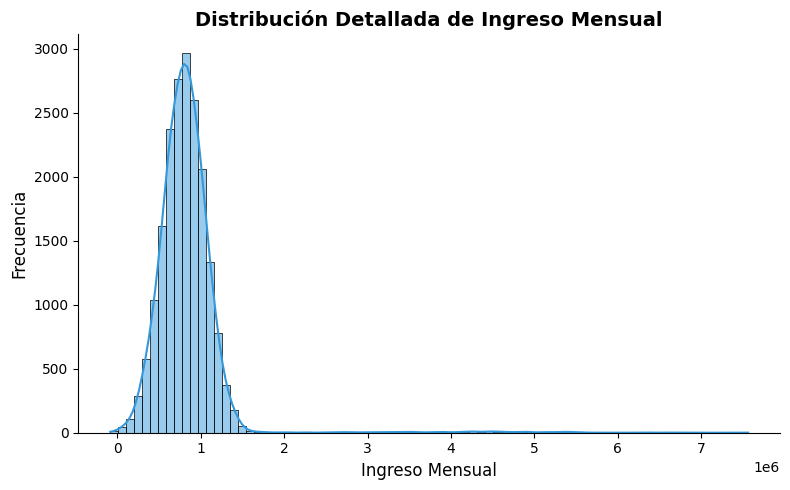

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(data['ingreso_mensual'], bins=80, kde=True, color='#3498db')
plt.title('Distribución Detallada de Ingreso Mensual', fontsize=14, fontweight='bold')
plt.xlabel('Ingreso Mensual', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

#### *2.9.2 Distribución Deuda Total*

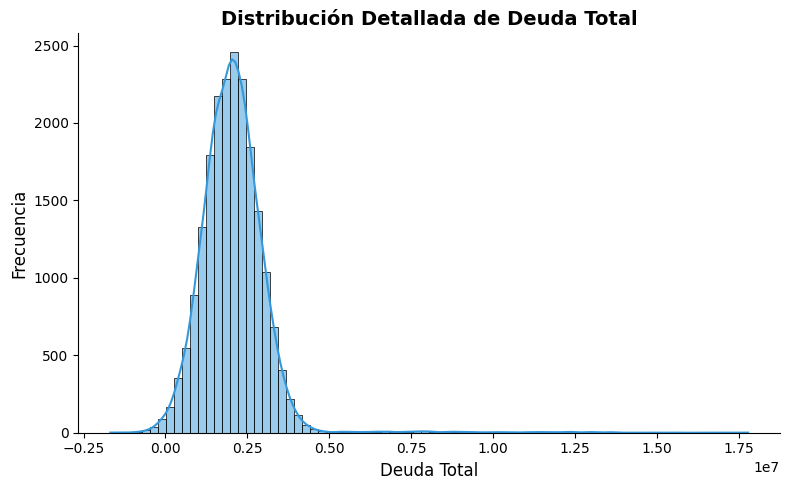

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(data['deuda_total'], bins=80, kde=True, color='#3498db')
plt.title('Distribución Detallada de Deuda Total', fontsize=14, fontweight='bold')
plt.xlabel('Deuda Total', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

#### *2.9.3 Distribución Gasto Mensual*

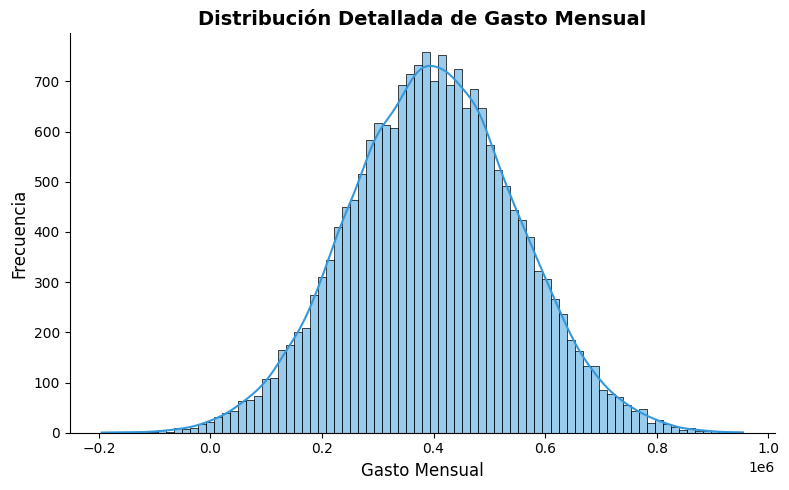

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(data['gasto_mensual'], bins=80, kde=True, color='#3498db')
plt.title('Distribución Detallada de Gasto Mensual', fontsize=14, fontweight='bold')
plt.xlabel('Gasto Mensual', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

#### *2.9.4 Distribución Score Crediticio*

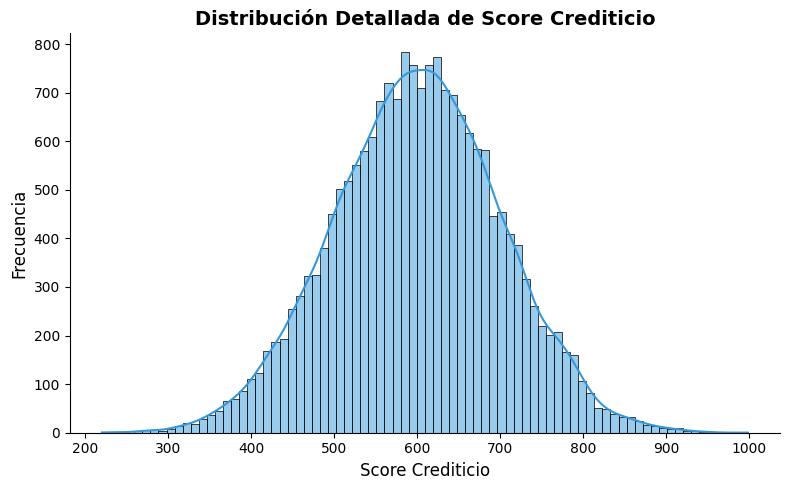

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(data['score_crediticio'], bins=80, kde=True, color='#3498db')
plt.title('Distribución Detallada de Score Crediticio', fontsize=14, fontweight='bold')
plt.xlabel('Score Crediticio', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

####  *2.9.5 Análisis de Distribuciones*

* **Distribuciones Asimétricas (Ingreso Mensual y Deuda Total):** Presentan una clara asimetría positiva (una cola larga estirada hacia la derecha). Esto nos indica que la gran mayoría de los clientes se concentra en sueldos y deudas estándar o moderadas, pero existe un grupo minoritario muy marcado que registra montos multimillonarios atípicos.

* **Distribuciones Normales (Gasto Mensual y Score Crediticio):** Tienen un comportamiento excelente. Ambas forman una campana de Gauss casi perfecta, lo que significa que los datos se distribuyen de manera simétrica y predecible alrededor de sus promedios centrales (aprox. $400.000 de gasto y 600 puntos de score).

### 2.10 Perfilamiento de la Variable Objetivo (Desbalance de Clases)

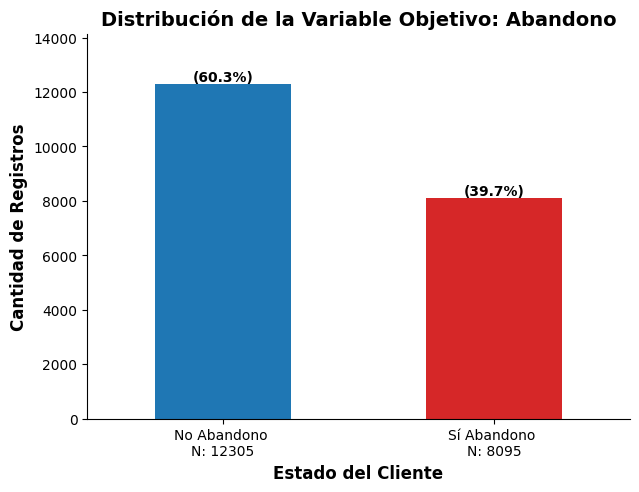

In [23]:
# 1. Calculamos las frecuencias directamente de la columna
frecuencias = data['abandono'].value_counts()
total_clientes = len(data['abandono'].dropna())

# 2. Graficamos asignando colores lógicos de negocio
ax = frecuencias.plot(kind="bar", color=["#1f77b4", "#d62728"], rot=0, figsize=(7, 5))

# Configuramos los títulos y nombres de ejes
plt.title("Distribución de la Variable Objetivo: Abandono", fontweight="bold", fontsize=14)
plt.xlabel("Estado del Cliente", fontweight="bold", fontsize=12)
plt.ylabel("Cantidad de Registros", fontweight="bold", fontsize=12)
plt.xticks([0, 1], [f"No Abandono \nN: {frecuencias[0]}", f"Sí Abandono \nN: {frecuencias[1]}"])

# 3. Agregamos (Porcentaje) a cada barra
for i, count in enumerate(frecuencias):
    porcentaje = (count / total_clientes) * 100
    plt.text(i, count, f"\n({porcentaje:.1f}%)", ha='center', va='bottom', fontweight='bold')

# 3. Quitamos las lineas superior y derecha (spines)
sns.despine()
# Extendemos el límite del eje Y un 15% para que los números no choquen con el borde superior
plt.ylim(0, frecuencias.max() * 1.15)
plt.show()

**Observación:** El gráfico revela una proporción aproximada de 60/40 en nuestra variable objetivo (12.305 retenidos vs. 8.095 fugas), destacando dos puntos clave:

* **Impacto Comercial:** Una tasa de abandono del 39.7% es una métrica crítica para la empresa, lo que justifica plenamente la construcción de este modelo predictivo para frenar la fuga.

* **Impacto para el Modelo:** Nos enfrentamos a un desbalance de clases moderado. El algoritmo tendrá ejemplos suficientes para aprender de ambos grupos, pero este ligero sesgo nos obliga a utilizar métricas como el Recall o el F1-Score (en lugar de la simple Exactitud o Accuracy) durante la evaluación futura para asegurar que el modelo realmente detecte a los clientes en riesgo.

### 2.11 Análisis Bivariado Numérico: Antigüedad vs. Abandono

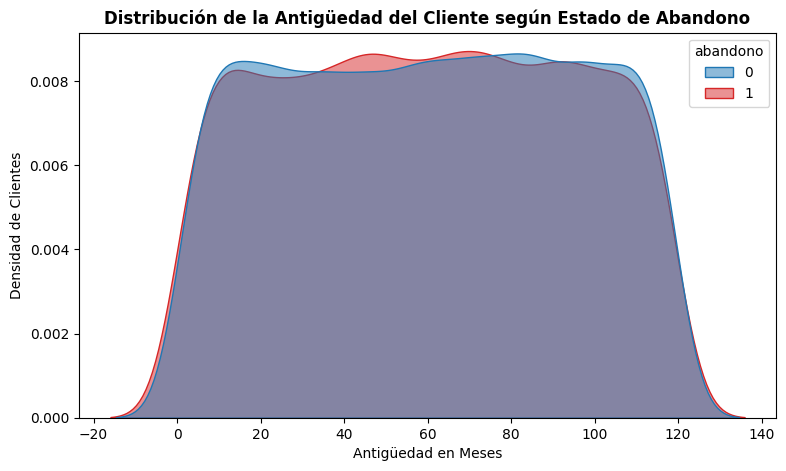

In [24]:
plt.figure(figsize=(9, 5))
# Analizamos la densidad de la antigüedad dividida por el estado de abandono
sns.kdeplot(data=data, x='antiguedad_meses', hue='abandono', fill=True, common_norm=False, palette=["#1f77b4", "#d62728"], alpha=0.5)
plt.title("Distribución de la Antigüedad del Cliente según Estado de Abandono", fontsize=12, fontweight='bold')
plt.xlabel("Antigüedad en Meses")
plt.ylabel("Densidad de Clientes")
plt.show()

**Observación:** Evaluamos cómo cambia la distribución de una variable continua según la fuga. Se observa gráficamente si los clientes con menor antigüedad concentran una mayor densidad de abandono, lo que representaría un problema de retención temprana para el negocio.

### 2.12 Análisis Bivariado Categórico: Tasa de Abandono por Tipo de Plan

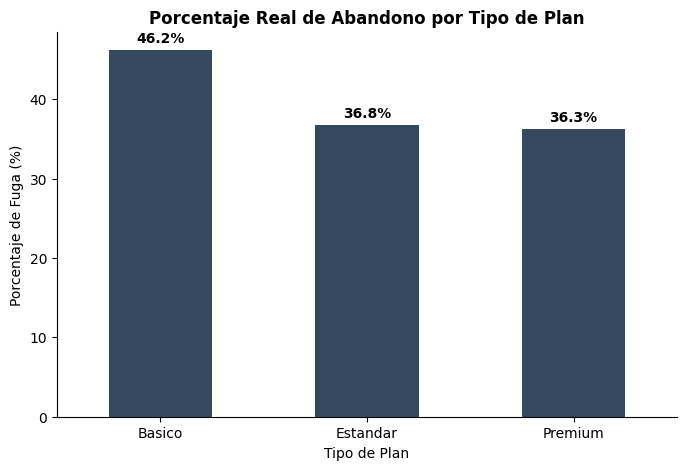

In [25]:
# Calculamos matemáticamente la proporción real de fuga agrupada por plan
tasa_churn_plan = data.groupby('tipo_plan')['abandono'].mean() * 100

plt.figure(figsize=(8, 5))
ax = tasa_churn_plan.sort_values(ascending=False).plot(kind='bar', color='#34495e', rot=0)
plt.title("Porcentaje Real de Abandono por Tipo de Plan", fontsize=12, fontweight='bold')
plt.xlabel("Tipo de Plan")
plt.ylabel("Porcentaje de Fuga (%)")

# Aplicamos Storytelling añadiendo etiquetas de datos sobre las barras
for i, val in enumerate(tasa_churn_plan.sort_values(ascending=False)):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')

sns.despine()
plt.show()

**Observación:** Tal como exige la metodología de analítica de clientes, no basta con contar cuántos usuarios hay por plan; calculamos por categoría. Esto permite identificar visualmente y sin esfuerzo cognitivo en qué plan la proporción de abandono es mayor.

### 2.13 Análisis Multivariado: Matriz de Correlación Orientada al Abandono

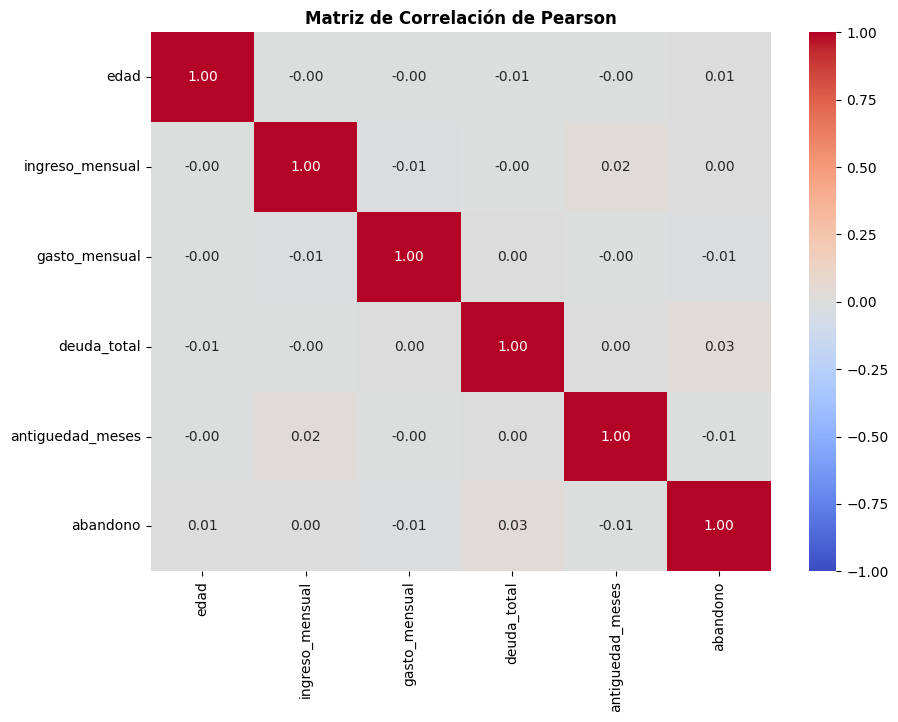

In [26]:
plt.figure(figsize=(10, 7))
# Filtramos las características numéricas clave en su estado original
columnas_corr = ['edad', 'ingreso_mensual', 'gasto_mensual', 'deuda_total', 'antiguedad_meses', 'abandono']
sns.heatmap(data[columnas_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación de Pearson", fontsize=12, fontweight='bold')
plt.show()

**Observación:** El uso de un mapa de calor nos permite resaltar patrones rápidos de asociación lineal entre las variables cuantitativas y la variable objetivo. Además, este paso es fundamental para auditar y descartar la presencia de multicolinealidad severa antes de avanzar hacia el entrenamiento de modelos lineales.